# Modal Expansion Reconstruction Visualization

此 Notebook 為 `Dubiner-Tikhonov` 正規化的 3D 重建視覺化腳本，方便進行測試與呈現。

In [2]:
from __future__ import annotations
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as mtri

# --- 1. Path Setup ---
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 引入核心模組 - 使用新的模組化API
from src.core.generators import build_nodes
from src.core.render_utils import VERTICES_2D, VERTICES_3D, exact_solution
from src.reconstruction import modal_reconstruct_at_bary_dubiner_tikhonov

# 確保輸出資料夾存在
OUT_DIR = PROJECT_ROOT / "outputs" / "modal_expansion"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory ready: {OUT_DIR}")

Output directory ready: /Users/user/code/Simplex-DG-solver/outputs/modal_expansion


In [3]:
# --- 2. Shared Utilities ---
def make_dense_bary_grid(n: int = 90) -> np.ndarray:
    bary = []
    for i in range(n + 1):
        for j in range(n + 1 - i):
            b0 = i / n
            b1 = j / n
            b2 = 1.0 - b0 - b1
            bary.append([b0, b1, b2])
    return np.array(bary, dtype=float)

# 共用的網格與參數設定
target_bary = make_dense_bary_grid(n=180)
methods = ["table1", "table2"]
ks = [1, 2, 3, 4]

## Dubiner-Tikhonov Regularization

$$\mathbf{a} = \left( V_{\text{ref}}^T W V_{\text{ref}} + \lambda_{\text{reg}}^2 L^T L \right)^{-1} V_{\text{ref}}^T W \mathbf{u}$$

- $V_{\text{ref}}^T W V_{\text{ref}}$ 是標準的加權質量矩陣 (Weighted Mass Matrix)。
- $\lambda_{\text{reg}}$ 是正規化參數 (lambda_reg)。
- $L$ 是 Tikhonov 懲罰矩陣。

$$\mathbf{u}_{\text{target}} = V_{\text{target}} \mathbf{a}$$

Saved: /Users/user/code/Simplex-DG-solver/outputs/modal_expansion/modal_expansion_reconstruction_3d_table1_table2_k1_to_k4.png


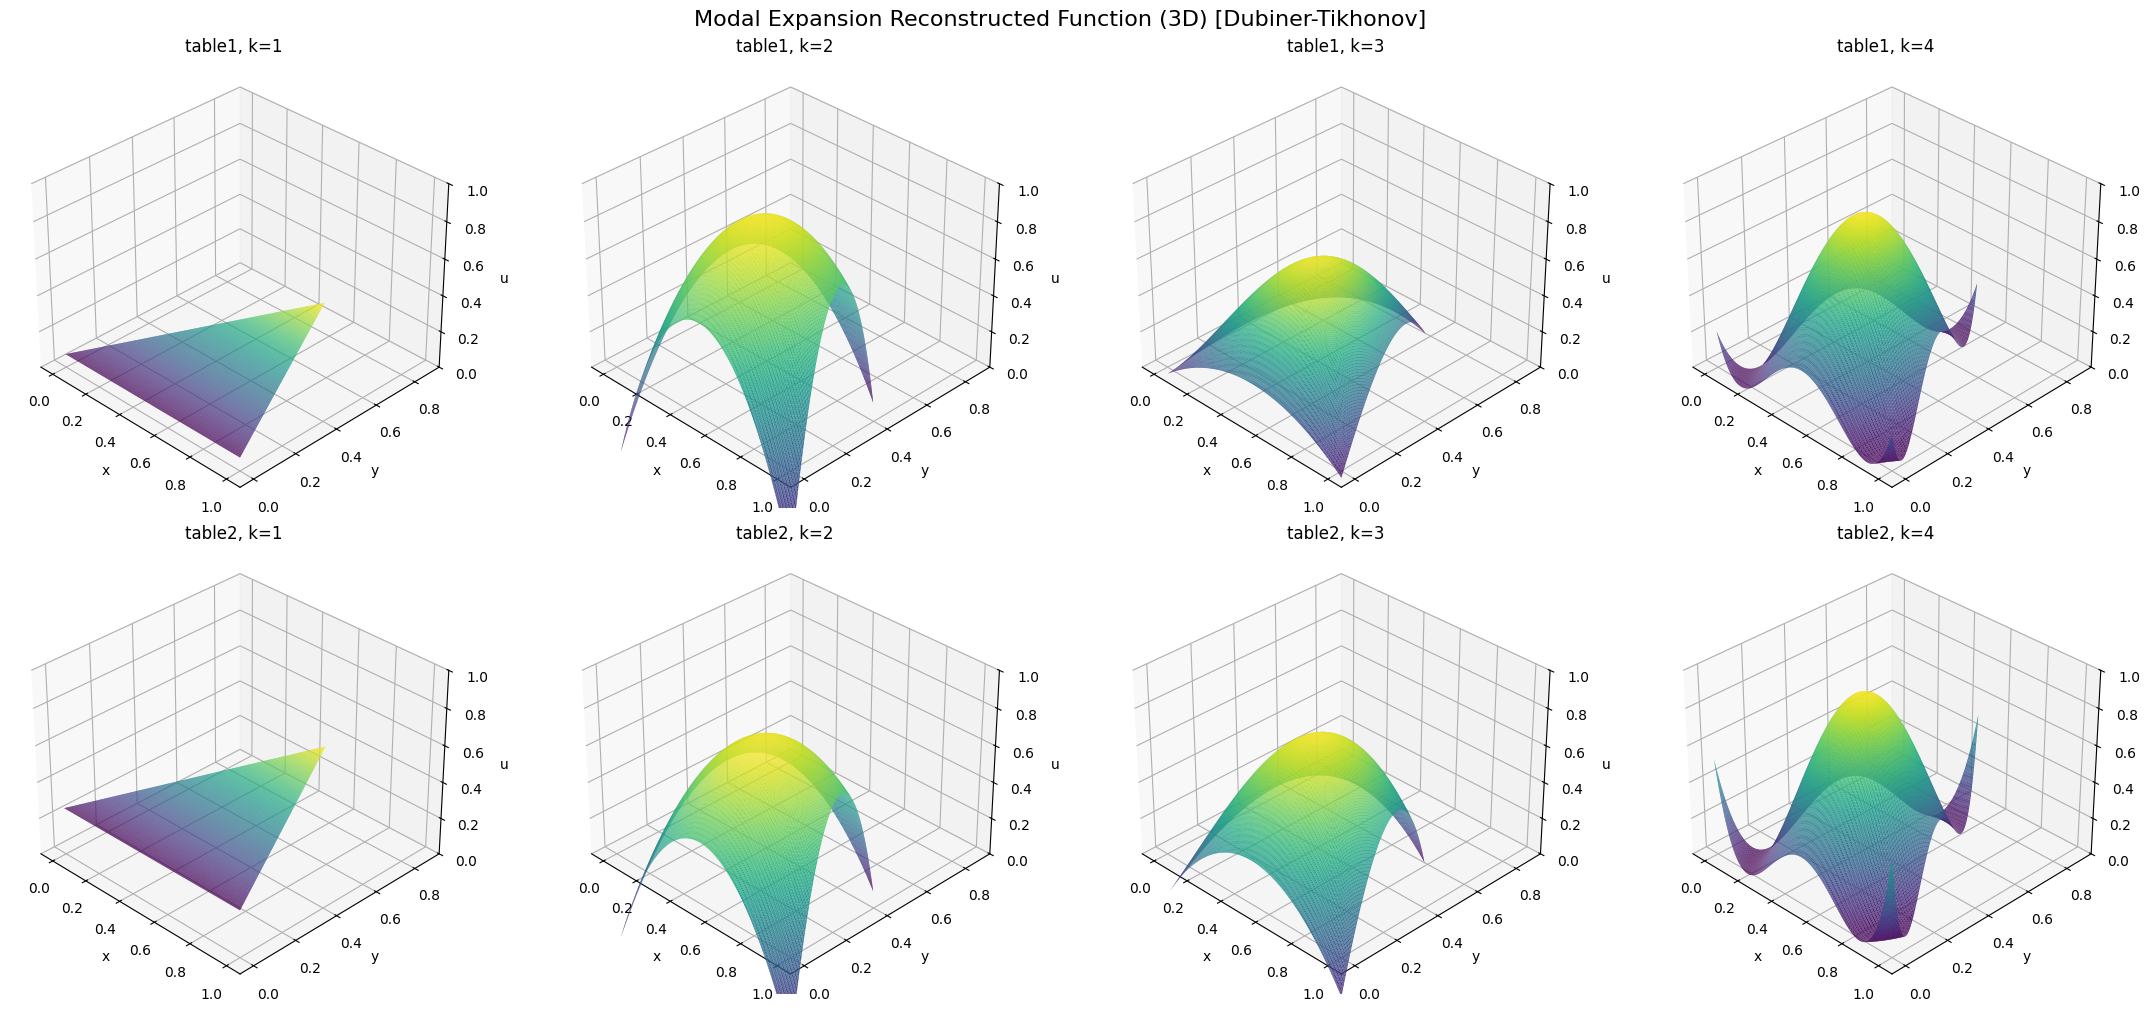

In [4]:
def reconstruct_tikhonov(method: str, k: int, target_bary: np.ndarray):
    nodes = build_nodes(method, k, VERTICES_2D, VERTICES_3D)
    known_xy = np.array([n.barycentric @ VERTICES_2D for n in nodes])
    known_vals = exact_solution(known_xy[:, 0], known_xy[:, 1])

    target_xy, target_vals = modal_reconstruct_at_bary_dubiner_tikhonov(
        nodes=nodes,
        known_vals=known_vals,
        target_bary=target_bary,
        vertices_2d=VERTICES_2D,
        k=k,
        lambda_reg=0,
        apply_filter=False,
    )
    return target_xy, target_vals

def plot_tikhonov_cases():
    fig3d = plt.figure(figsize=(22, 10), constrained_layout=True)
    for r, method in enumerate(methods):
        for c, k in enumerate(ks):
            xy, vals = reconstruct_tikhonov(method, k, target_bary)
            triang = mtri.Triangulation(xy[:, 0], xy[:, 1])

            idx = r * 4 + c + 1
            ax3d = fig3d.add_subplot(2, 4, idx, projection="3d")
            ax3d.plot_trisurf(
                xy[:, 0], xy[:, 1], vals,
                triangles=triang.triangles,
                cmap="viridis", linewidth=0.05, edgecolor="none", antialiased=True
            )
            ax3d.set_title(f"{method}, k={k}")
            ax3d.set_xlabel("x")
            ax3d.set_ylabel("y")
            ax3d.set_zlabel("u")
            ax3d.set_zlim(0.0, 1.0)
            ax3d.view_init(elev=32, azim=-45)

    fig3d.suptitle("Modal Expansion Reconstructed Function (3D) [Dubiner-Tikhonov]", fontsize=16)
    out_3d = OUT_DIR / "modal_expansion_reconstruction_3d_table1_table2_k1_to_k4.png"
    fig3d.savefig(out_3d, dpi=500)
    print(f"Saved: {out_3d}")
    plt.show()

plot_tikhonov_cases()